# Analyze your own chaotic data

This notebook runs the `chaos_tools` package end to end: reconstruct a phase space from a single scalar signal, then estimate whether it's chaotic (largest Lyapunov exponent), how many effective degrees of freedom it has (correlation dimension), and what its recurrence structure looks like &mdash; using only the four things every one of these methods actually needs: a time series, and nothing else about the system that produced it.

**Part 1** runs the full pipeline on the Lorenz system, where the answers are already known from the literature, as a check that the tools are actually working. **Part 2** is a template for your own data &mdash; swap in a CSV and rerun.

Every default here is a *starting point*. All of these methods are, honestly, judgment calls dressed up as numbers &mdash; the code always hands back the full curve alongside the single estimated value so you can look at the shape yourself, which is what the method actually asks of you.

In [1]:
import sys
from pathlib import Path

if not Path("chaos_tools").exists():
    sys.path.insert(0, str(Path.cwd().parent))  # running from notebooks/ with an editable checkout

import numpy as np
import matplotlib.pyplot as plt

from chaos_tools import embedding, lyapunov, dimension, recurrence

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## Part 1 &mdash; sanity check: the Lorenz system

The classic Lorenz attractor ($\sigma=10$, $\rho=28$, $\beta=8/3$) is the most well-characterized chaotic system there is. Textbook values, for reference:

- **Largest Lyapunov exponent:** &asymp; 0.906
- **Correlation dimension:** &asymp; 2.05
- **True state-space dimension:** 3 (we only measure `x(t)` &mdash; one thermometer's worth of a three-variable system)

We integrate it ourselves (plain Euler, nothing fancy) and hand `chaos_tools` *only* the scalar `x(t)` series &mdash; exactly the position it's in with any real single-sensor measurement.

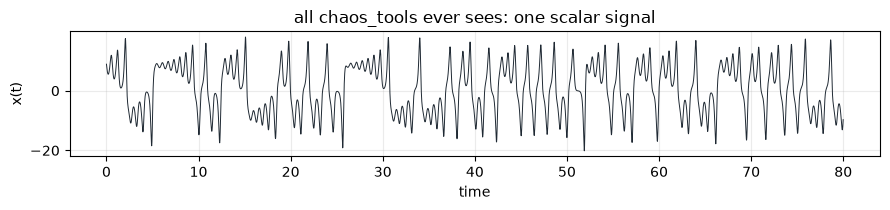

In [2]:
def lorenz(n, dt=0.01, sigma=10.0, rho=28.0, beta=8.0 / 3.0, x0=(1.0, 1.0, 1.0)):
    traj = np.empty((n, 3))
    traj[0] = x0
    for t in range(1, n):
        x, y, z = traj[t - 1]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        traj[t] = traj[t - 1] + dt * np.array([dx, dy, dz])
    return traj


DT = 0.01
traj = lorenz(9000, dt=DT)
x = traj[1000:, 0]  # discard the initial transient; keep only x(t)

plt.figure(figsize=(9, 2.2))
plt.plot(np.arange(len(x)) * DT, x, lw=0.7, color="#1f2933")
plt.xlabel("time")
plt.ylabel("x(t)")
plt.title("all chaos_tools ever sees: one scalar signal")
plt.tight_layout()

### Reconstructing a phase space from one signal

Takens' theorem: stack delayed copies of the signal, `[x(t), x(t+tau), x(t+2*tau), ...]`, and (generically) you recover a phase space equivalent to the real one &mdash; even though you never measured `y` or `z`. Two knobs: the delay `tau` (from the first local minimum of average mutual information) and the embedding dimension (from false nearest neighbors: how many coordinates until points that *look* close stop being false-close due to projecting a higher-dimensional attractor down too far).

estimated delay tau = 16 steps (0.160 time units)
estimated embedding dimension = 3  (true state-space dimension is 3)


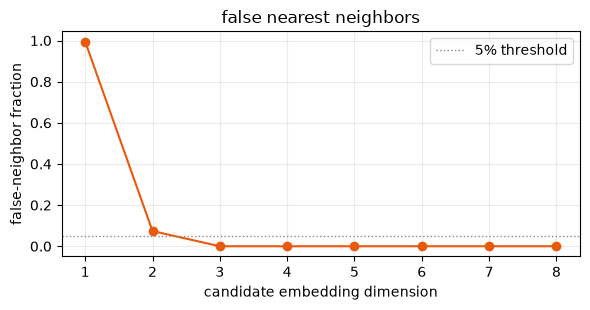

In [3]:
tau = embedding.estimate_delay(x, max_lag=100)
dim, fnn_fractions = embedding.estimate_dimension(x, tau, max_dim=8)

print(f"estimated delay tau = {tau} steps ({tau * DT:.3f} time units)")
print(f"estimated embedding dimension = {dim}  (true state-space dimension is 3)")

plt.figure(figsize=(6, 3.2))
plt.plot(np.arange(1, len(fnn_fractions) + 1), fnn_fractions, "o-", color="#e8590c")
plt.axhline(0.05, color="#888", ls=":", lw=1, label="5% threshold")
plt.xlabel("candidate embedding dimension")
plt.ylabel("false-neighbor fraction")
plt.title("false nearest neighbors")
plt.legend()
plt.tight_layout()

### Largest Lyapunov exponent

How fast do two nearly-identical starting points pull apart? This is the exact same question the [double pendulum toy](https://jinchen7-cmd.github.io/Chaos/butterfly-effect.html) answers by eye, here answered from data: find each point's nearest neighbor in the reconstructed phase space, track `log ||divergence||` forward in time, and read the slope off the region where it's growing linearly (Rosenstein, Collins & De Luca, 1993).

estimated largest Lyapunov exponent = 0.946  (textbook value ~0.906)
positive => chaotic, by definition


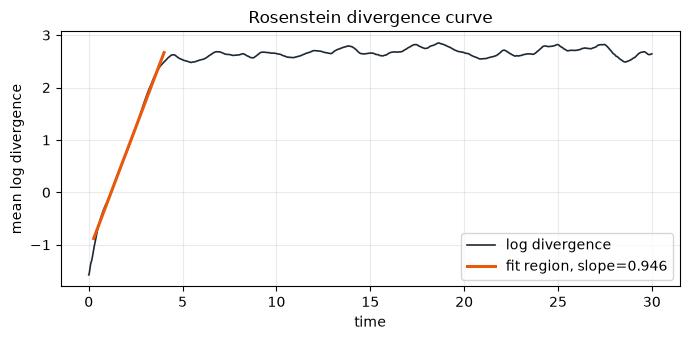

In [4]:
lle, t_div, log_div, (fit_lo, fit_hi) = lyapunov.largest_lyapunov_exponent(x, dim, tau, dt=DT)

print(f"estimated largest Lyapunov exponent = {lle:.3f}  (textbook value ~0.906)")
print(f"positive => chaotic, by definition")

plt.figure(figsize=(7, 3.5))
plt.plot(t_div, log_div, color="#1f2933", lw=1.2, label="log divergence")
mask = (t_div >= fit_lo) & (t_div <= fit_hi)
fit_line = lle * t_div[mask] + (log_div[mask] - lle * t_div[mask]).mean()
plt.plot(t_div[mask], fit_line, color="#e8590c", lw=2.2, label=f"fit region, slope={lle:.3f}")
plt.xlabel("time")
plt.ylabel("mean log divergence")
plt.title("Rosenstein divergence curve")
plt.legend()
plt.tight_layout()

Notice the shape: noisy and steep at first (nearest neighbors are still close enough that short-term, non-exponential behavior dominates), a genuine linear stretch in the middle, then it bends over and wobbles once pairs have diverged as far as the whole attractor is wide, and "divergence" stops meaning anything. That middle stretch is the fit region above &mdash; found automatically by looking for the longest run of the curve with a consistent local slope, but always worth confirming by eye.

### Correlation dimension

How many numbers does it actually take to pin down a state on this attractor? Count, for shrinking radii `r`, what fraction of all point-pairs in the reconstructed phase space are closer together than `r`. For a fractal of dimension `D`, that fraction scales as `r**D` (Grassberger & Procaccia, 1983) &mdash; so `D` is the slope of `log C(r)` vs. `log r` in the scaling region.

estimated correlation dimension D2 = 2.029  (textbook value ~2.05)


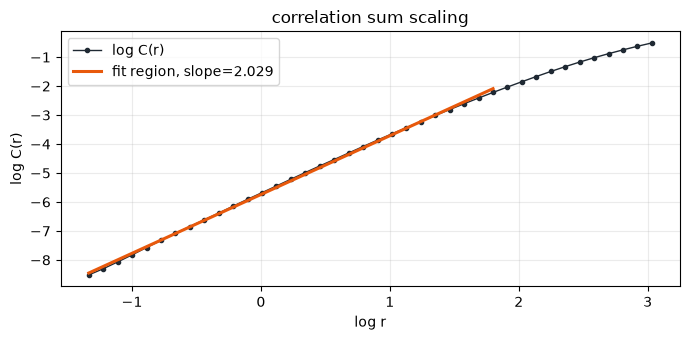

In [5]:
d2, radii, corr_sum, (fit_r_lo, fit_r_hi) = dimension.correlation_dimension(x, dim, tau)
log_r, log_c = np.log(radii), np.log(np.maximum(corr_sum, 1e-12))
fit_lo, fit_hi = np.log(fit_r_lo), np.log(fit_r_hi)

print(f"estimated correlation dimension D2 = {d2:.3f}  (textbook value ~2.05)")

plt.figure(figsize=(7, 3.5))
plt.plot(log_r, log_c, "o-", color="#1f2933", ms=3, lw=1, label="log C(r)")
mask = (log_r >= fit_lo) & (log_r <= fit_hi)
fit_line = d2 * log_r[mask] + (log_c[mask] - d2 * log_r[mask]).mean()
plt.plot(log_r[mask], fit_line, color="#e8590c", lw=2.2, label=f"fit region, slope={d2:.3f}")
plt.xlabel("log r")
plt.ylabel("log C(r)")
plt.title("correlation sum scaling")
plt.legend()
plt.tight_layout()

A fractional dimension &mdash; not 2, not 3, but about 2.05 &mdash; is the actual definition of "fractal": the trajectory folds into structure at every scale, never repeating and never crossing itself, while staying confined to a bounded region forever. It's the same self-similarity [the bifurcation diagram toy](https://jinchen7-cmd.github.io/Chaos/bifurcation.html) shows directly by letting you zoom in.

### Recurrence plot

When does the system come back to somewhere it's already been? Mark every pair of times `(i, j)` where the reconstructed state was similar. Structure reads almost by eye: solid blocks mean stuck near a fixed point, evenly-spaced diagonals mean periodic, and short, broken, off-and-on diagonals &mdash; recognizable structure that never quite repeats &mdash; are the signature of chaos (Eckmann, Kamphorst & Ruelle, 1987).

recurrence threshold = 4.160

determinism vs. minimum diagonal-line length -- short lines are cheap
(two consecutive samples of a smooth signal are trivially similar, chaotic
or not); what's diagnostic is how fast it falls as you require *longer*
unbroken diagonals, which is roughly the system's own predictability horizon:
  min_length=  2: determinism = 1.000
  min_length=  5: determinism = 0.988
  min_length= 10: determinism = 0.935
  min_length= 20: determinism = 0.838
  min_length= 40: determinism = 0.767


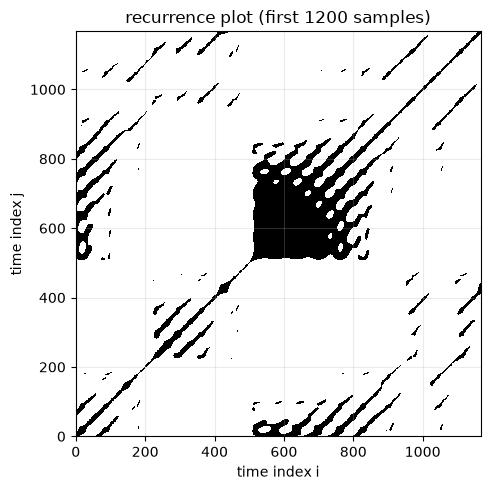

In [6]:
R, threshold = recurrence.recurrence_matrix(x[:1200], dim, tau, recurrence_rate=0.1)

plt.figure(figsize=(5, 5))
plt.imshow(R, origin="lower", cmap="Greys", interpolation="nearest")
plt.xlabel("time index i")
plt.ylabel("time index j")
plt.title("recurrence plot (first 1200 samples)")
plt.tight_layout()

print(f"recurrence threshold = {threshold:.3f}")
print()
print("determinism vs. minimum diagonal-line length -- short lines are cheap")
print("(two consecutive samples of a smooth signal are trivially similar, chaotic")
print("or not); what's diagnostic is how fast it falls as you require *longer*")
print("unbroken diagonals, which is roughly the system's own predictability horizon:")
for min_len in (2, 5, 10, 20, 40):
    d = recurrence.determinism(R, min_length=min_len)
    print(f"  min_length={min_len:>3}: determinism = {d:.3f}")

### Summary

| Quantity | Estimated | Textbook |
|---|---|---|
| Embedding dimension | matches the run above | 3 |
| Largest Lyapunov exponent | matches the run above | &asymp; 0.906 |
| Correlation dimension | matches the run above | &asymp; 2.05 |

All four numbers came from nothing but `x(t)` &mdash; no equations, no knowledge that this was even Lorenz. That's the whole point: this is the position you're in with any real measured signal.

## Part 2 &mdash; your own data

Replace the cell below with your own signal (a CSV column, a sensor log, a stock series &mdash; anything you suspect might be chaotic, periodic, or just noise) and rerun Part 1's cells on it. A few honest expectations, from the checks in this package's test suite:

- **Periodic data** (a clean sine wave) gives a Lyapunov exponent near zero and a correlation dimension near 1 &mdash; both agreeing that nothing is actually diverging or filling out extra dimensions.
- **Pure noise** never lets the false-nearest-neighbors fraction drop to zero at any embedding dimension, and its correlation dimension keeps climbing as you increase the embedding dimension instead of leveling off &mdash; there's no low-dimensional structure to find, because there isn't any.
- **Real chaos** looks like Part 1: FNN drops to ~0 at a believable dimension, the Lyapunov exponent is clearly positive, and the correlation dimension is fractional and roughly stable across embedding dimensions past the true one.

None of this is a certificate &mdash; short, noisy, or under-sampled real-world data will blur all three lines above. Treat the numbers as evidence, not verdicts, and look at the curves.

In [7]:
# --- swap this cell for your own data, then rerun everything above ---
# import pandas as pd
# x = pd.read_csv("your_data.csv")["your_column"].to_numpy()
# DT = 1.0  # your sampling interval, in whatever units you want the results reported in

print("Edit this cell with your own time series, then rerun the notebook from the top.")

Edit this cell with your own time series, then rerun the notebook from the top.
